In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestRegressor, VotingRegressor
from sklearn.model_selection import train_test_split
import xgboost as xgb
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.impute import SimpleImputer

In [2]:
df = pd.read_csv("../cleanData.csv")

###  One-Hot Encoding for Month

In [3]:
month_dummies = pd.get_dummies(df['Month'], prefix='Month', drop_first=False)
df = pd.concat([df, month_dummies], axis=1)
df = df.drop(columns=['Month', 'Date', 'Year'])
df.drop(columns=['Month_sin', 'Month_cos'], inplace=True)

In [4]:
df.sample(4)

,Latitude_Degrees,Longitude_Degrees,Depth,Average_Bleaching,ClimSST,Temperature_Kelvin,Temperature_Mean,Temperature_Minimum,Temperature_Maximum,Temperature_Kelvin_Standard_Deviation,...,Month_3,Month_4,Month_5,Month_6,Month_7,Month_8,Month_9,Month_10,Month_11,Month_12
6009,28.557472,34.523889,5.0,0.0,262.15,300.0175,296.9775,291.6525,302.1475,2.1425,...,False,False,False,False,False,False,True,False,False,False
211,-23.443111,151.909389,2.0,5.0,297.41,296.0400,297.3500,292.8300,302.8600,2.2200,...,False,False,False,False,False,False,True,False,False,False
4668,18.191694,-76.454611,7.0,0.0,262.15,303.0150,301.0325,297.4450,304.6100,1.1850,...,False,False,False,True,False,False,False,False,False,False
2631,4.812806,103.675944,7.0,0.5,302.25,301.8700,301.7800,296.8500,305.5200,1.3100,...,False,False,False,False,False,True,False,False,False,False


In [5]:
df.columns

Index(['Latitude_Degrees', 'Longitude_Degrees', 'Depth', 'Average_Bleaching',
       'ClimSST', 'Temperature_Kelvin', 'Temperature_Mean',
       'Temperature_Minimum', 'Temperature_Maximum',
       'Temperature_Kelvin_Standard_Deviation', 'Windspeed', 'SSTA',
       'SSTA_Standard_Deviation', 'SSTA_Minimum', 'SSTA_Maximum',
       'SSTA_Frequency', 'SSTA_Frequency_Standard_Deviation',
       'SSTA_FrequencyMax', 'SSTA_FrequencyMean', 'SSTA_DHW',
       'SSTA_DHW_Standard_Deviation', 'SSTA_DHWMax', 'SSTA_DHWMean', 'TSA',
       'TSA_Standard_Deviation', 'TSA_Minimum', 'TSA_Maximum', 'TSA_Mean',
       'TSA_Frequency', 'TSA_Frequency_Standard_Deviation', 'TSA_FrequencyMax',
       'TSA_FrequencyMean', 'TSA_DHW', 'TSA_DHW_Standard_Deviation',
       'TSA_DHWMax', 'TSA_DHWMean', 'SSTA_Rolling_Mean', 'TSA_Rolling_Mean',
       'Month_1', 'Month_2', 'Month_3', 'Month_4', 'Month_5', 'Month_6',
       'Month_7', 'Month_8', 'Month_9', 'Month_10', 'Month_11', 'Month_12'],
      dtype='object')

# PCA

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [7]:
X = df.drop("Average_Bleaching", axis=1)
Y = df["Average_Bleaching"]

In [8]:
X_train_raw, X_test_raw, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

In [9]:
X_train_raw_month, X_test_raw_month = X_train_raw[['Month_1', 'Month_2', 'Month_3', 'Month_4', 'Month_5', 'Month_6',
       'Month_7', 'Month_8', 'Month_9', 'Month_10', 'Month_11', 'Month_12']].copy(), X_test_raw[['Month_1', 'Month_2', 'Month_3', 'Month_4', 'Month_5', 'Month_6',
       'Month_7', 'Month_8', 'Month_9', 'Month_10', 'Month_11', 'Month_12']].copy()

X_train_raw = X_train_raw.drop(columns= ['Month_1', 'Month_2', 'Month_3', 'Month_4', 'Month_5', 'Month_6',
       'Month_7', 'Month_8', 'Month_9', 'Month_10', 'Month_11', 'Month_12'])
X_test_raw = X_test_raw.drop(columns= ['Month_1', 'Month_2', 'Month_3', 'Month_4', 'Month_5', 'Month_6',
       'Month_7', 'Month_8', 'Month_9', 'Month_10', 'Month_11', 'Month_12'])

In [10]:
imputer = SimpleImputer(strategy='median')
X_train_imp = imputer.fit_transform(X_train_raw)
X_test_imp = imputer.transform(X_test_raw)

scaler = StandardScaler()
X_train_ss = scaler.fit_transform(X_train_imp)
X_test_ss = scaler.transform(X_test_imp)

In [11]:
pca = PCA(n_components=16)
X_train_pca = pca.fit_transform(X_train_ss)
X_test_pca = pca.transform(X_test_ss)

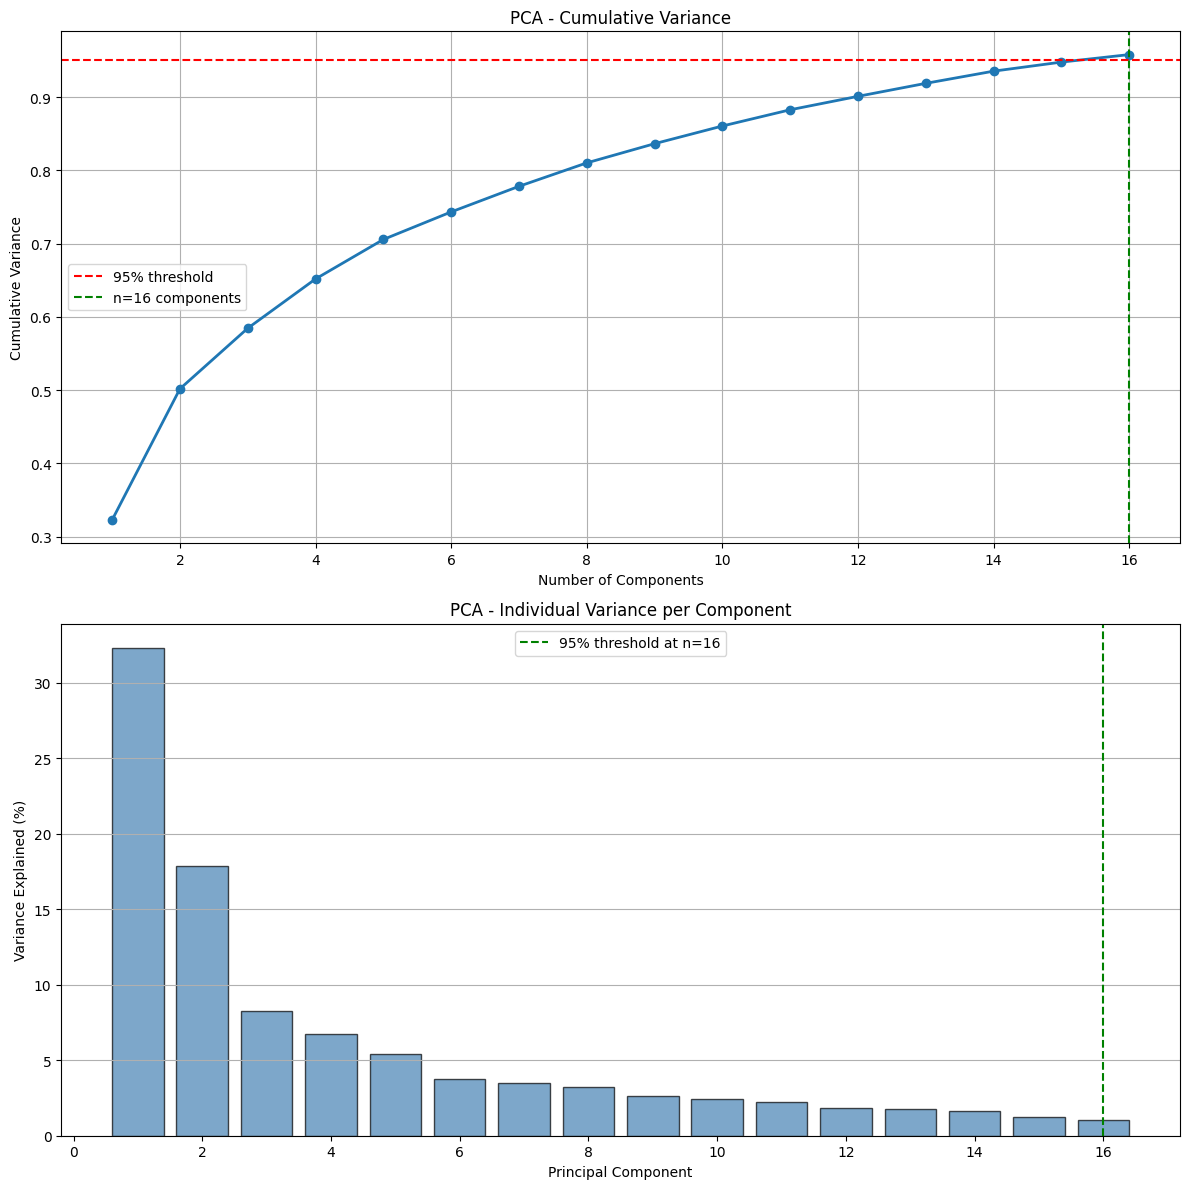

✅ Components needed for 95% variance: 16
✅ Variance explained by 16 components: 0.9580


In [12]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 12))

# --- Plot 1: Cumulative Variance (your existing plot) ---
cumvar = np.cumsum(pca.explained_variance_ratio_)
n_components_95 = np.argmax(cumvar >= 0.95) + 1

ax1.plot(range(1, len(cumvar)+1), cumvar, marker='o', linewidth=2)
ax1.axhline(y=0.95, color='r', linestyle='--', label='95% threshold')
ax1.axvline(x=n_components_95, color='g', linestyle='--', 
            label=f'n={n_components_95} components')
ax1.set_xlabel('Number of Components')
ax1.set_ylabel('Cumulative Variance')
ax1.set_title('PCA - Cumulative Variance')
ax1.legend()
ax1.grid(True)

# --- Plot 2: Individual variance per component (bar chart) ---
ax2.bar(range(1, len(pca.explained_variance_ratio_)+1), 
        pca.explained_variance_ratio_ * 100,
        color='steelblue', alpha=0.7, edgecolor='black')
ax2.axvline(x=n_components_95, color='g', linestyle='--',
            label=f'95% threshold at n={n_components_95}')
ax2.set_xlabel('Principal Component')
ax2.set_ylabel('Variance Explained (%)')
ax2.set_title('PCA - Individual Variance per Component')
ax2.legend()
ax2.grid(True, axis='y')

plt.tight_layout()
plt.savefig('pca_variance.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"✅ Components needed for 95% variance: {n_components_95}")
print(f"✅ Variance explained by {n_components_95} components: {cumvar[n_components_95-1]:.4f}")

In [13]:
print(pca.explained_variance_)

[11.9481676   6.62262147  3.05922606  2.49057874  1.99362763  1.39127365
  1.29274225  1.18374026  0.96979471  0.89276632  0.81991637  0.67903677
  0.65636674  0.61542897  0.45708856  0.37924476]


In [14]:
X_test_pca

array([[ 0.44798991,  1.29497667,  1.94800709, ..., -0.44856979,
        -0.17648884, -0.03309998],
       [ 0.30108327, -1.09402909, -0.84581165, ...,  0.79827368,
        -0.40863679, -0.88707305],
       [ 0.8790804 ,  0.84208766,  1.25919547, ..., -0.03130162,
         0.5804982 , -0.33190849],
       ...,
       [-3.76208542,  0.68328134, -1.17247461, ..., -0.22999318,
        -0.42276368,  0.1210378 ],
       [-1.39828545,  0.68243697,  0.30286606, ...,  0.40675596,
         0.37768982, -0.07333658],
       [-4.1061129 ,  0.54223661, -1.29404909, ..., -0.616873  ,
         0.01393414,  0.21976098]], shape=(1223, 16))

In [15]:
X_test_raw_month

,Month_1,Month_2,Month_3,Month_4,Month_5,Month_6,Month_7,Month_8,Month_9,Month_10,Month_11,Month_12
2905,False,False,False,False,False,True,False,False,False,False,False,False
319,False,True,False,False,False,False,False,False,False,False,False,False
3649,False,False,False,False,False,False,True,False,False,False,False,False
5883,False,False,False,False,False,False,False,False,False,False,False,True
4622,False,False,False,False,False,False,False,True,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...
4355,False,False,False,False,True,False,False,False,False,False,False,False
3132,False,False,False,False,True,False,False,False,False,False,False,False
1112,False,False,False,False,True,False,False,False,False,False,False,False
1242,False,False,False,False,False,False,False,False,False,False,False,True


In [16]:
X_train_pca_df = pd.DataFrame(X_train_pca, columns=[f'PC{i+1}' for i in range(X_train_pca.shape[1])])
X_test_pca_df = pd.DataFrame(X_test_pca, columns=[f'PC{i+1}' for i in range(X_test_pca.shape[1])])

X_train_raw_month = X_train_raw_month.reset_index(drop=True)
X_test_raw_month = X_test_raw_month.reset_index(drop=True)

X_train_pca = pd.concat([X_train_pca_df, X_train_raw_month], axis=1)
X_test_pca = pd.concat([X_test_pca_df, X_test_raw_month], axis=1)

# lazyPredict

In [ ]:
from lazypredict.Supervised import LazyRegressor
from sklearn.model_selection import train_test_split

In [ ]:
reg = LazyRegressor(verbose=0, ignore_warnings=True, custom_metric=None)
models, predictions = reg.fit(X_train_pca, X_test_pca, y_train, y_test)

print(models)

In [17]:
import optuna
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.ensemble import ExtraTreesRegressor, HistGradientBoostingRegressor
from sklearn.model_selection import cross_val_score

# OpTuna

In [ ]:
# ── prepare a version of X_train that already has month columns ──
month_cols = ['Month_1','Month_2','Month_3','Month_4','Month_5','Month_6',
              'Month_7','Month_8','Month_9','Month_10','Month_11','Month_12']

X_train_no_month = X_train_raw.copy()   # numeric only (month already dropped earlier)
X_train_month    = X_train_raw_month.reset_index(drop=True)

# helper: run CV with month columns reattached after PCA inside each fold
def cv_with_month(pipeline, X_num, X_mon, y, cv=4):
    from sklearn.model_selection import KFold
    kf = KFold(n_splits=cv, shuffle=True, random_state=42)
    scores = []
    for train_idx, val_idx in kf.split(X_num):
        X_num_tr, X_num_val = X_num.iloc[train_idx], X_num.iloc[val_idx]
        X_mon_tr  = X_mon.iloc[train_idx].reset_index(drop=True)
        X_mon_val = X_mon.iloc[val_idx].reset_index(drop=True)
        y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]

        # fit the pipeline (impute+scale+pca) on numeric only
        steps_no_model = Pipeline(pipeline.steps[:-1])
        X_tr_pca  = steps_no_model.fit_transform(X_num_tr)
        X_val_pca = steps_no_model.transform(X_num_val)

        n_pcs = X_tr_pca.shape[1]
        pc_cols = [f'PC{i+1}' for i in range(n_pcs)]

        X_tr_final  = pd.concat([pd.DataFrame(X_tr_pca,  columns=pc_cols), X_mon_tr],  axis=1)
        X_val_final = pd.concat([pd.DataFrame(X_val_pca, columns=pc_cols), X_mon_val], axis=1)

        model = pipeline.steps[-1][1]
        model.fit(X_tr_final, y_tr)
        scores.append(model.score(X_val_final, y_val))   # R²
    return np.mean(scores)

In [ ]:
def hgb_objective(trial):
    model = HistGradientBoostingRegressor(
        max_iter         = trial.suggest_int  ("max_iter",          50, 400),
        max_depth        = trial.suggest_int  ("max_depth",          3,  15),
        learning_rate    = trial.suggest_float("learning_rate",  0.005, 0.1),
        min_samples_leaf = trial.suggest_int  ("min_samples_leaf",   1,  50),
        l2_regularization= trial.suggest_float("l2_regularization", 0.0, 1.0),
        random_state=42
    )
    pipeline = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler',  StandardScaler()),
        ('pca',     PCA(n_components=16)),
        ('model',   model)
    ])
    return cv_with_month(pipeline, X_train_no_month, X_train_month, y_train)

hgb_study = optuna.create_study(direction="maximize")
hgb_study.optimize(hgb_objective, n_trials=50)
print("========== HGB BEST ==========")
print(hgb_study.best_params)
print(f"Best R²: {hgb_study.best_value:.4f}")


In [ ]:
def et_objective(trial):
    model = ExtraTreesRegressor(
        n_estimators     = trial.suggest_int  ("n_estimators",  50, 400),
        max_depth        = trial.suggest_int  ("max_depth",      5,  40),
        min_samples_leaf = trial.suggest_int  ("min_samples_leaf",1,  5),
        max_features     = trial.suggest_categorical("max_features", ["sqrt","log2"]),
        n_jobs=-1, random_state=42
    )
    pipeline = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler',  StandardScaler()),
        ('pca',     PCA(n_components=16)),
        ('model',   model)
    ])
    return cv_with_month(pipeline, X_train_no_month, X_train_month, y_train)

et_study = optuna.create_study(direction="maximize")
et_study.optimize(et_objective, n_trials=50)
print("========== ET BEST ==========")
print(et_study.best_params)
print(f"Best R²: {et_study.best_value:.4f}")

In [ ]:
def xgb_objective(trial):
    model = xgb.XGBRegressor(
        n_estimators      = trial.suggest_int  ("n_estimators",   50, 400),
        learning_rate     = trial.suggest_float("learning_rate", 0.005, 0.1),
        max_depth         = trial.suggest_int  ("max_depth",       3,  15),
        subsample         = trial.suggest_float("subsample",      0.5, 1.0),
        colsample_bytree  = trial.suggest_float("colsample_bytree",0.5, 1.0),
        n_jobs=-1, random_state=42
    )
    pipeline = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler',  StandardScaler()),
        ('pca',     PCA(n_components=16)),
        ('model',   model)
    ])
    return cv_with_month(pipeline, X_train_no_month, X_train_month, y_train)

xgb_study = optuna.create_study(direction="maximize")
xgb_study.optimize(xgb_objective, n_trials=50)
print("========== XGB BEST ==========")
print(xgb_study.best_params)
print(f"Best R²: {xgb_study.best_value:.4f}")

# Start

In [18]:
hgb_model = HistGradientBoostingRegressor(
    max_iter=211,
    max_depth=10,
    learning_rate=0.0485,
    min_samples_leaf=11,
    l2_regularization=0.8831,
    random_state=42
)
# {'max_iter': 211, 'max_depth': 10, 'learning_rate': 0.04846251191044525, 'min_samples_leaf': 11, 'l2_regularization': 0.8830944711161548}

et_model = ExtraTreesRegressor(
    n_estimators=167,
    max_depth=34,
    min_samples_leaf=1,
    max_features='sqrt',
    n_jobs=-1,
    random_state=42
)
# {'n_estimators': 167, 'max_depth': 34, 'min_samples_leaf': 1, 'max_features': 'sqrt'}

xgb_model = xgb.XGBRegressor(
    n_estimators=386,
    learning_rate=0.0223,
    max_depth=8,
    subsample=0.736,
    colsample_bytree=0.801,
    n_jobs=-1,
    random_state=42
)
# {'n_estimators': 386, 'learning_rate': 0.022277335089809572, 'max_depth': 8, 'subsample': 0.7356910839788313, 'colsample_bytree': 0.8012150390694037}


rf_model = RandomForestRegressor(
    n_estimators=272, 
    max_depth=23, 
    min_samples_leaf=1,
    max_features='sqrt',
    n_jobs=-1, 
    random_state=42
)

In [19]:
voting = VotingRegressor([
    ('hgb', hgb_model),
    ('et',  et_model),
    ('xgb', xgb_model),
    # ('rf', rf_model)
])
voting.fit(X_train_pca, y_train)

# Evaluation
preds = voting.predict(X_test_pca)
r2 = r2_score(y_test, preds)
rmse = np.sqrt(mean_squared_error(y_test, preds))

print(f"\n--- Leakage-Free Results ---")
print(f"R-squared: {r2:.4f}")
print(f"RMSE: {rmse:.4f}")


--- Leakage-Free Results ---
R-squared: 0.4576
RMSE: 7.1340


# K-Fold

In [ ]:
from sklearn.model_selection import KFold
import numpy as np

n_splits = 4
kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)

r2_scores   = []
rmse_scores = []

# Separate month columns before the loop
month_cols = ['Month_1','Month_2','Month_3','Month_4','Month_5','Month_6',
              'Month_7','Month_8','Month_9','Month_10','Month_11','Month_12']

X_month = X[month_cols].copy()
X_no_month = X.drop(columns=month_cols)

for fold, (train_idx, test_idx) in enumerate(kf.split(X), 1):
    # Split numeric and month separately
    X_fold_train, X_fold_test       = X_no_month.iloc[train_idx], X_no_month.iloc[test_idx]
    month_fold_train, month_fold_test = X_month.iloc[train_idx].reset_index(drop=True), \
                                        X_month.iloc[test_idx].reset_index(drop=True)
    y_fold_train, y_fold_test       = Y.iloc[train_idx], Y.iloc[test_idx]

    # Impute → Scale → PCA (numeric only)
    imputer     = SimpleImputer(strategy='median')
    X_train_imp = imputer.fit_transform(X_fold_train)
    X_test_imp  = imputer.transform(X_fold_test)

    scaler      = StandardScaler()
    X_train_ss  = scaler.fit_transform(X_train_imp)
    X_test_ss   = scaler.transform(X_test_imp)

    pca         = PCA(n_components=16)
    X_train_pca = pca.fit_transform(X_train_ss)
    X_test_pca  = pca.transform(X_test_ss)

    # Convert PCA output to DataFrame and attach month columns
    n_pcs = X_train_pca.shape[1]
    pc_cols = [f'PC{i+1}' for i in range(n_pcs)]

    X_train_final = pd.concat([
        pd.DataFrame(X_train_pca, columns=pc_cols),
        month_fold_train
    ], axis=1)
    X_test_final = pd.concat([
        pd.DataFrame(X_test_pca, columns=pc_cols),
        month_fold_test
    ], axis=1)

    # Train & evaluate
    voting = VotingRegressor([
        ('hgb', hgb_model), ('et', et_model), ('xgb', xgb_model)
    ])
    voting.fit(X_train_final, y_fold_train)

    preds = voting.predict(X_test_final)
    r2_scores.append(r2_score(y_fold_test, preds))
    rmse_scores.append(np.sqrt(mean_squared_error(y_fold_test, preds)))

    print(f"Fold {fold}  →  R²: {r2_scores[-1]:.4f}  |  RMSE: {rmse_scores[-1]:.4f}")

print(f"\n--- {n_splits}-Fold Summary ---")
print(f"R²   mean: {np.mean(r2_scores):.4f}  ±  {np.std(r2_scores):.4f}")
print(f"RMSE mean: {np.mean(rmse_scores):.4f}  ±  {np.std(rmse_scores):.4f}")